# 02 — Cobertura DIEST (corpus-alvo da Fase 2)

Filtra `data/interim/metadados.parquet` para o subset da **Diretoria de
Estudos e Políticas do Estado, das Instituições e da Democracia (DIEST)**
e descreve o corpus-alvo que irá para a Fase 2 (download de PDFs + Docling).

O filtro combina dois sinais:
- `orgunit_uuid == 38b33462-dc75-43f2-9bda-1f3c54757ae7` (linkagem nova,
  típica de itens pós-2020);
- `contributor_other` casando com `DIEST` ou `Diretoria de Estudos e
  Políticas do Estado` (histórico completo).

O subset é persistido em `data/interim/metadados_diest.parquet`.

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path('..').resolve()))
from src.scraping import filter_by_diretoria

SRC = Path('../data/interim/metadados.parquet')
DEST = Path('../data/interim/metadados_diest.parquet')
df = pd.read_parquet(SRC)
print(f'Corpus completo: {len(df):,} documentos')

Corpus completo: 17,943 documentos


In [2]:
diest = filter_by_diretoria(df, 'DIEST')
diest.to_parquet(DEST, index=False)
print(f'DIEST: {len(diest):,} documentos ({len(diest)/len(df):.1%} do corpus)')
print(f'Escrito em {DEST}')

DIEST: 91 documentos (0.5% do corpus)
Escrito em ../data/interim/metadados_diest.parquet


## Quebra dos sinais usados no filtro

Quantos itens foram capturados por UUID vs. por texto livre.

In [3]:
DIEST_UUID = '38b33462-dc75-43f2-9bda-1f3c54757ae7'
by_uuid = df['orgunit_uuid'].fillna('').str.contains(DIEST_UUID, regex=False)
by_text = df['contributor_other'].fillna('').str.contains(
    r'(?:\bDIEST\b|Diretoria de Estudos e Políticas do Estado)',
    case=False, regex=True,
)
print(f'Por orgunit_uuid:       {int(by_uuid.sum()):>6}')
print(f'Por contributor_other:  {int(by_text.sum()):>6}')
print(f'Por ambos:              {int((by_uuid & by_text).sum()):>6}')
print(f'União (DIEST total):    {int((by_uuid | by_text).sum()):>6}')

Por orgunit_uuid:           27
Por contributor_other:      91
Por ambos:                  27
União (DIEST total):        91


## Cobertura temporal e de PDF

In [4]:
anos = diest['ano'].dropna().astype(int)
print(f'Ano mínimo: {anos.min()}')
print(f'Ano máximo: {anos.max()}')
print(f'Sem ano:    {diest["ano"].isna().sum()}')
print()
print(f'Com handle:  {diest["handle"].notna().sum():>6} ({diest["handle"].notna().mean():.1%})')
print(f'Com resumo:  {(diest["resumo"] != "").sum():>6} ({(diest["resumo"] != "").mean():.1%})')

Ano mínimo: 2011
Ano máximo: 2026
Sem ano:    1

Com handle:      90 (98.9%)
Com resumo:      91 (100.0%)


In [5]:
print('=== Tipos documentais (DIEST) ===')
print(diest['tipo'].fillna('(sem tipo)').value_counts().to_string())

=== Tipos documentais (DIEST) ===
tipo
Journal                    38
Working paper              31
Journal Article            15
Preliminary Publication     4
Report                      3


=== Documentos DIEST por década ===
decada
2010    22
2020    68


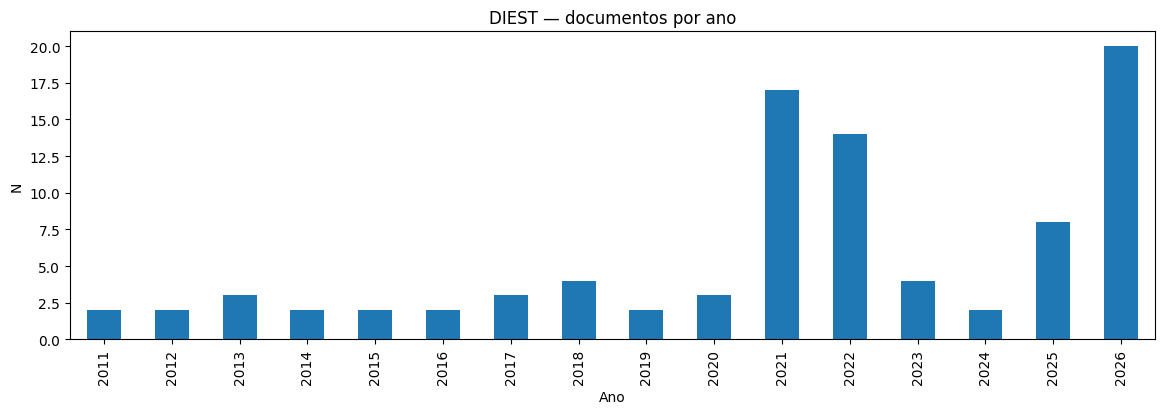

In [6]:
d = diest.dropna(subset=['ano']).copy()
d['decada'] = (d['ano'].astype(int) // 10) * 10
print('=== Documentos DIEST por década ===')
print(d['decada'].value_counts().sort_index().to_string())
ax = d['ano'].astype(int).value_counts().sort_index().plot(
    kind='bar', figsize=(14, 4), title='DIEST — documentos por ano'
)
ax.set_xlabel('Ano'); ax.set_ylabel('N');

In [7]:
autores = diest['autores'].fillna('').str.split('; ').explode().str.strip()
autores = autores[autores != '']
print('=== Top 30 autores DIEST ===')
print(autores.value_counts().head(30).to_string())

=== Top 30 autores DIEST ===
autores
Daniel Pitangueira de Avelino            4
Itaquê Santana Barbosa                   4
Koga, Natália Massaco                    3
Jéssica Vasconcelos de Abreu             3
Maria Estela Capuano Villar              3
Marcella Simões Penello Meirelles        3
Azevedo, Daniel A. de                    3
Danilo Santa Cruz Coelho                 3
Walter Antonio Desiderá Neto             2
Denise do Carmo Direito                  2
Gustavo Luedemann                        2
Acioly, Luciana                          2
Luciana Mendes Santos Servo              2
Santos, Érica Rocha dos                  2
Bertogna, João Pedro Sussel              2
Rosa, Luiza Gomes Luz                    2
Oliveira, Raissa Menezes de              2
Silva, Virginia Rocha da                 2
Frederico Augusto Barbosa da Silva       2
Daniel Ricardo de Castro Cerqueira       2
Pedro Lucas de Moura Palotti             1
Paulo de Tarso Frazão Soares Linhares    1
Anderson Henrique

In [8]:
palavras = diest['palavras_chave'].fillna('').str.split(', ').explode().str.strip()
palavras = palavras[palavras != '']
print('=== Top 40 palavras-chave DIEST ===')
print(palavras.value_counts().head(40).to_string())

=== Top 40 palavras-chave DIEST ===
palavras_chave
Política                                        31
Estado                                          31
Democracia                                      25
Desenvolvimento econômico e social              22
Políticas públicas                              13
Políticas Públicas                               7
Desenvolvimento                                  7
Participação social                              5
Políticas Sociais                                5
Violência                                        3
Criminalidade                                    3
Violência sexual                                 3
Estupro                                          3
Planejamento                                     3
Governo                                          3
BRICS                                            2
Políticas públicas informadas por evidências     2
Políticas em direitos humanos                    2
Institucionalização            

In [9]:
pivot = d.groupby(['decada', 'tipo']).size().unstack(fill_value=0)
pivot = pivot.loc[:, pivot.sum().sort_values(ascending=False).head(8).index]
print('=== Tipo × década (DIEST) ===')
pivot

=== Tipo × década (DIEST) ===


tipo,Journal,Working paper,Journal Article,Preliminary Publication,Report
decada,,,,,
2010,19,2,0,0,1
2020,18,29,15,4,2
